In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url="https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"

df=pd.read_csv(url)


print(df.head())
print(df.shape)
print(df.columns)
print(df.info())

       country  year         pop continent  lifeExp   gdpPercap
0  Afghanistan  1952   8425333.0      Asia   28.801  779.445314
1  Afghanistan  1957   9240934.0      Asia   30.332  820.853030
2  Afghanistan  1962  10267083.0      Asia   31.997  853.100710
3  Afghanistan  1967  11537966.0      Asia   34.020  836.197138
4  Afghanistan  1972  13079460.0      Asia   36.088  739.981106
(1704, 6)
Index(['country', 'year', 'pop', 'continent', 'lifeExp', 'gdpPercap'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   year       1704 non-null   int64  
 2   pop        1704 non-null   float64
 3   continent  1704 non-null   object 
 4   lifeExp    1704 non-null   float64
 5   gdpPercap  1704 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 80.0+ KB
None


In [ ]:
df = df.rename(columns={
    "lifeExp": "life_expectancy",
    "pop": "population",
    "gdpPercap": "gdp_per_capita"
})

print(df.head())
print(df.columns)

       country  year  population continent  life_expectancy  gdp_per_capita
0  Afghanistan  1952   8425333.0      Asia           28.801      779.445314
1  Afghanistan  1957   9240934.0      Asia           30.332      820.853030
2  Afghanistan  1962  10267083.0      Asia           31.997      853.100710
3  Afghanistan  1967  11537966.0      Asia           34.020      836.197138
4  Afghanistan  1972  13079460.0      Asia           36.088      739.981106
Index(['country', 'year', 'population', 'continent', 'life_expectancy',
       'gdp_per_capita'],
      dtype='object')


In [ ]:
print("Missing values in each column:")
print(df.isna().sum)

print("Number of duplicate rows:", df.duplicated().sum())

Missing values in each column:
<bound method DataFrame.sum of       country   year  population  continent  life_expectancy  gdp_per_capita
0       False  False       False      False            False           False
1       False  False       False      False            False           False
2       False  False       False      False            False           False
3       False  False       False      False            False           False
4       False  False       False      False            False           False
...       ...    ...         ...        ...              ...             ...
1699    False  False       False      False            False           False
1700    False  False       False      False            False           False
1701    False  False       False      False            False           False
1702    False  False       False      False            False           False
1703    False  False       False      False            False           False

[1704 rows x 

In [ ]:

df_clean = df.copy()

# Remove exact duplicate rows if any
if df_clean.duplicated().sum() > 0:
    df_clean = df_clean.drop_duplicates()

# Strip extra spaces from text columns
for col in ["country", "continent"]:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Ensure expected data types
df_clean["year"] = df_clean["year"].astype(int)
df_clean["population"] = df_clean["population"].astype(float)
df_clean["life_expectancy"] = df_clean["life_expectancy"].astype(float)
df_clean["gdp_per_capita"] = df_clean["gdp_per_capita"].astype(float)

print(df_clean.dtypes)
print(df_clean.head())

country             object
year                 int64
population         float64
continent           object
life_expectancy    float64
gdp_per_capita     float64
dtype: object
       country  year  population continent  life_expectancy  gdp_per_capita
0  Afghanistan  1952   8425333.0      Asia           28.801      779.445314
1  Afghanistan  1957   9240934.0      Asia           30.332      820.853030
2  Afghanistan  1962  10267083.0      Asia           31.997      853.100710
3  Afghanistan  1967  11537966.0      Asia           34.020      836.197138
4  Afghanistan  1972  13079460.0      Asia           36.088      739.981106


In [ ]:
# dirty_demo = df_clean.head(12).copy()

# # Deliberately introduce missing values for teaching practice
# dirty_demo.loc[2, "life_expectancy"] = np.nan
# dirty_demo.loc[5, "gdp_per_capita"] = np.nan

# print(dirty_demo)
# print(dirty_demo.isna().sum())

# # Fill missing numerical values using median
# clean_demo = dirty_demo.copy()
# clean_demo["life_expectancy"] = clean_demo["life_expectancy"].fillna(clean_demo["life_expectancy"].median())
# clean_demo["gdp_per_capita"] = clean_demo["gdp_per_capita"].fillna(clean_demo["gdp_per_capita"].median())

# print(clean_demo.isna().sum())
# print(clean_demo)

In [ ]:
num_of_country=df["country"].nunique()
print("Number of countries:", num_of_country)
num_of_cont=df["continent"].nunique()
print("Number of continents:", num_of_cont)

Number of countries: 142
Number of continents: 5


In [ ]:
latest_year=df["year"].max()
latest_data=df[df["year"]==latest_year].copy()
latest_data

,country,year,population,continent,life_expectancy,gdp_per_capita
11,Afghanistan,2007,31889923.0,Asia,43.828,974.580338
23,Albania,2007,3600523.0,Europe,76.423,5937.029526
35,Algeria,2007,33333216.0,Africa,72.301,6223.367465
47,Angola,2007,12420476.0,Africa,42.731,4797.231267
59,Argentina,2007,40301927.0,Americas,75.320,12779.379640
...,...,...,...,...,...,...
1655,Vietnam,2007,85262356.0,Asia,74.249,2441.576404
1667,West Bank and Gaza,2007,4018332.0,Asia,73.422,3025.349798
1679,"Yemen, Rep.",2007,22211743.0,Asia,62.698,2280.769906
1691,Zambia,2007,11746035.0,Africa,42.384,1271.211593


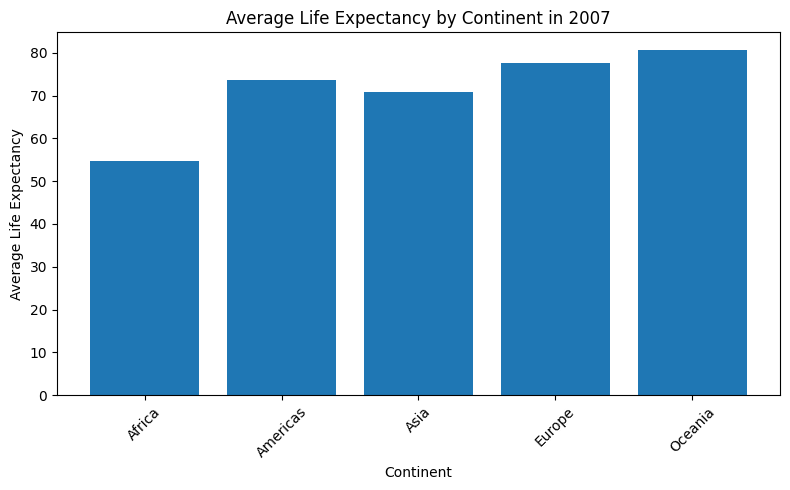

In [ ]:
# plt.plot(df["continent"],df["life_expectancy"])
# plt.show()
# Latest year ke data me continent-wise average life expectancy
continent_life = latest_data.groupby("continent")["life_expectancy"].mean()

plt.figure(figsize=(8, 5))
plt.bar(continent_life.index, continent_life.values)

plt.title(f"Average Life Expectancy by Continent in {latest_year}")
plt.xlabel("Continent")
plt.ylabel("Average Life Expectancy")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

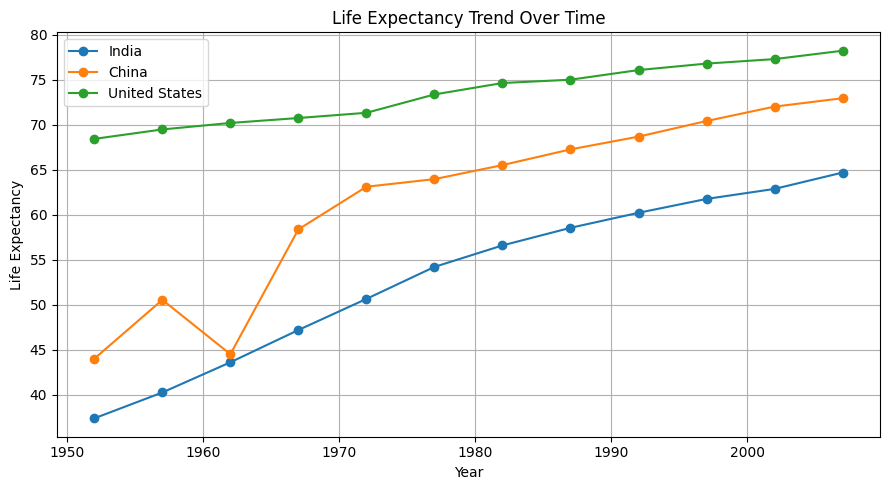

In [ ]:
# plt.plot(df["life_expectancy"],df["year"])
# plt.show()
selected_countries = ["India", "China", "United States"]
trend_df = df_clean[df_clean["country"].isin(selected_countries)]

plt.figure(figsize=(9, 5))

for country in selected_countries:
    country_df = trend_df[trend_df["country"] == country]
    plt.plot(country_df["year"],
             country_df["life_expectancy"],
             marker="o",
             label=country)

plt.title("Life Expectancy Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
continent_gdp_per_capita = latest_data.groupby('continent')['gdp_per_capita'].mean().reset_index()
display(continent_gdp_per_capita)

,continent,gdp_per_capita
0,Africa,3089.032605
1,Americas,11003.031625
2,Asia,12473.026870
3,Europe,25054.481636
4,Oceania,29810.188275


In [ ]:
top_5_gdp_countries = latest_data.sort_values(by='gdp_per_capita', ascending=False).head(5)
display(top_5_gdp_countries)

,country,year,population,continent,life_expectancy,gdp_per_capita
1151,Norway,2007,4627926.0,Europe,80.196,49357.19017
863,Kuwait,2007,2505559.0,Asia,77.588,47306.98978
1367,Singapore,2007,4553009.0,Asia,79.972,47143.17964
1619,United States,2007,301139947.0,Americas,78.242,42951.65309
755,Ireland,2007,4109086.0,Europe,78.885,40675.99635


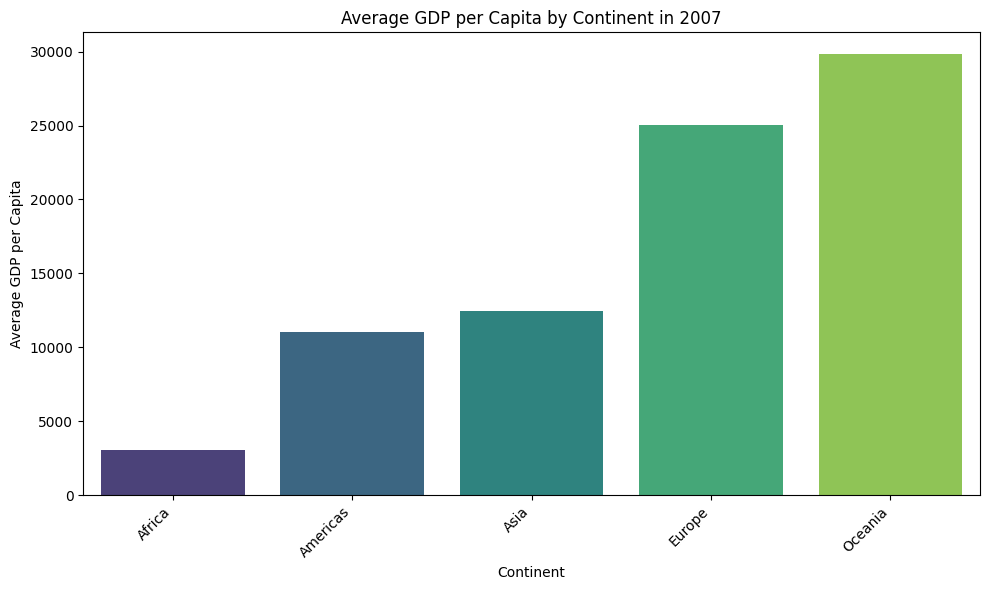

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='continent', y='gdp_per_capita', data=continent_gdp_per_capita, palette='viridis', hue='continent', legend=False)
plt.title(f'Average GDP per Capita by Continent in {latest_year}')
plt.xlabel('Continent')
plt.ylabel('Average GDP per Capita')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

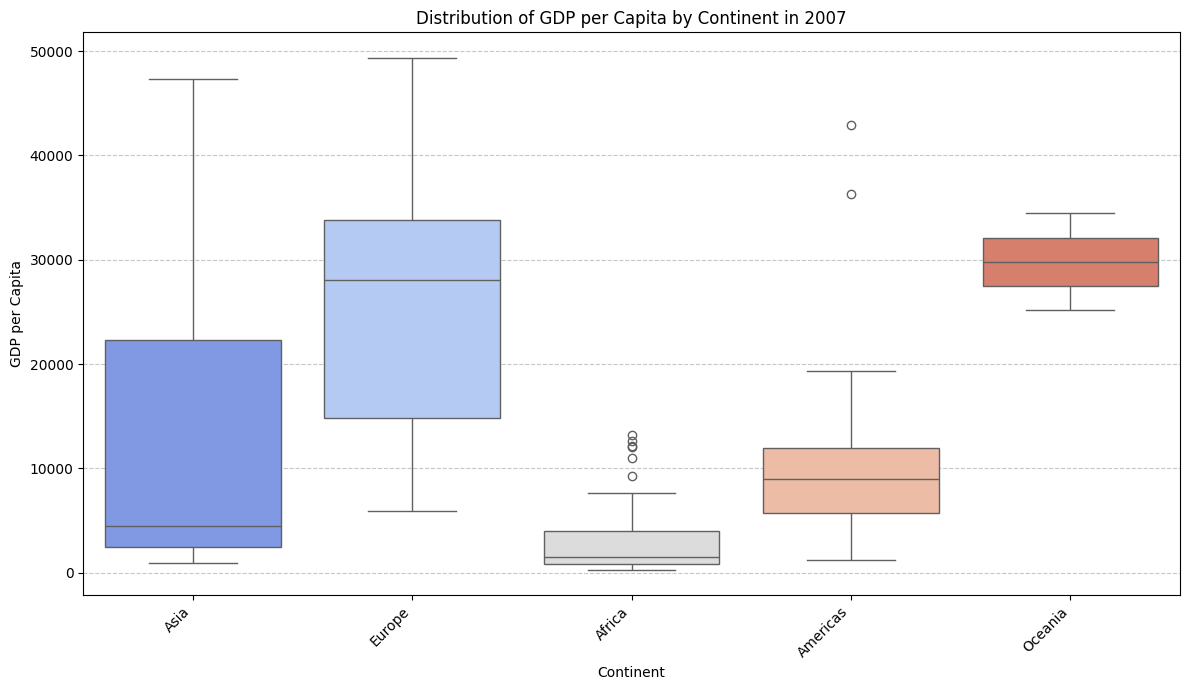

In [ ]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='continent', y='gdp_per_capita', data=latest_data, palette='coolwarm', hue='continent', legend=False)
plt.title(f'Distribution of GDP per Capita by Continent in {latest_year}')
plt.xlabel('Continent')
plt.ylabel('GDP per Capita')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

# Prepare the data
X = df_clean['gdp_per_capita'].values.reshape(-1, 1) # Independent variable (features)
y = df_clean['life_expectancy'].values # Dependent variable (target)

# Create and fit the model
model = LinearRegression()
model.fit(X, y)

# Get the coefficients
slope = model.coef_[0]
intercept = model.intercept_

print(f"Regression Equation: Life Expectancy = {slope:.4f} * GDP per Capita + {intercept:.2f}")
print(f"Coefficient (Slope): {slope:.4f}")
print(f"Intercept: {intercept:.2f}")

Regression Equation: Life Expectancy = 0.0008 * GDP per Capita + 53.96
Coefficient (Slope): 0.0008
Intercept: 53.96


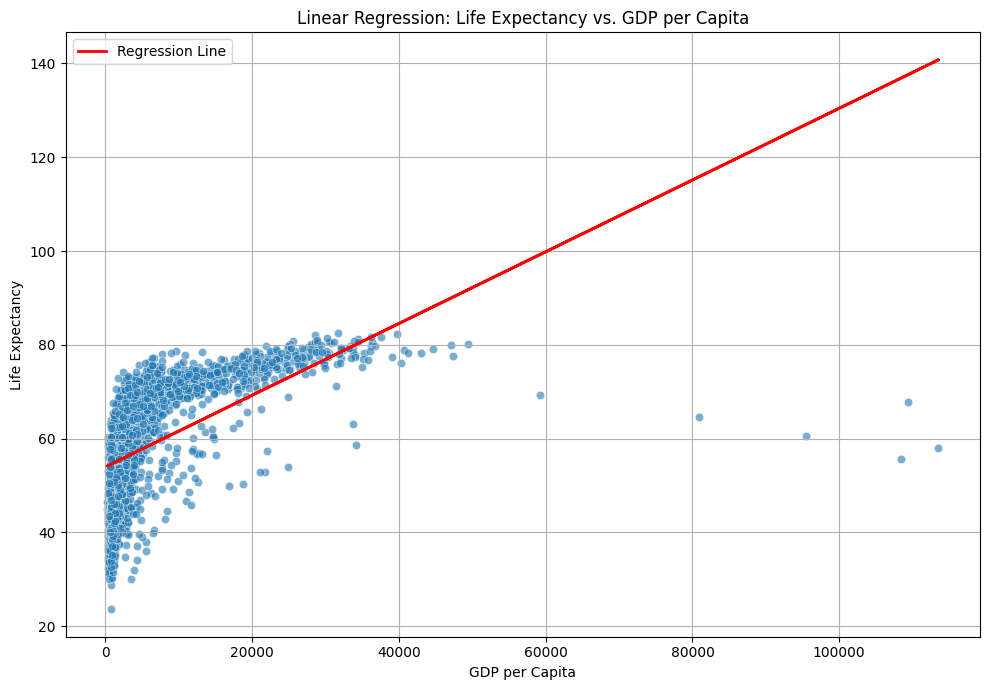

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x='gdp_per_capita', y='life_expectancy', data=df_clean, alpha=0.6)

# Plot the regression line
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Regression Line')

plt.title('Linear Regression: Life Expectancy vs. GDP per Capita')
plt.xlabel('GDP per Capita')
plt.ylabel('Life Expectancy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Get the list of top 5 wealthiest countries
top_5_countries_list = top_5_gdp_countries['country'].tolist()

# Calculate average life expectancy for top 5 countries in the latest year
life_exp_top_5 = latest_data[latest_data['country'].isin(top_5_countries_list)]['life_expectancy'].mean()

# Calculate average life expectancy for the rest of the world in the latest year
life_exp_rest_of_world = latest_data[~latest_data['country'].isin(top_5_countries_list)]['life_expectancy'].mean()

print(f"Average Life Expectancy for Top 5 Wealthiest Countries (in {latest_year}): {life_exp_top_5:.2f}")
print(f"Average Life Expectancy for the Rest of the World (in {latest_year}): {life_exp_rest_of_world:.2f}")

Average Life Expectancy for Top 5 Wealthiest Countries (in 2007): 78.98
Average Life Expectancy for the Rest of the World (in 2007): 66.57


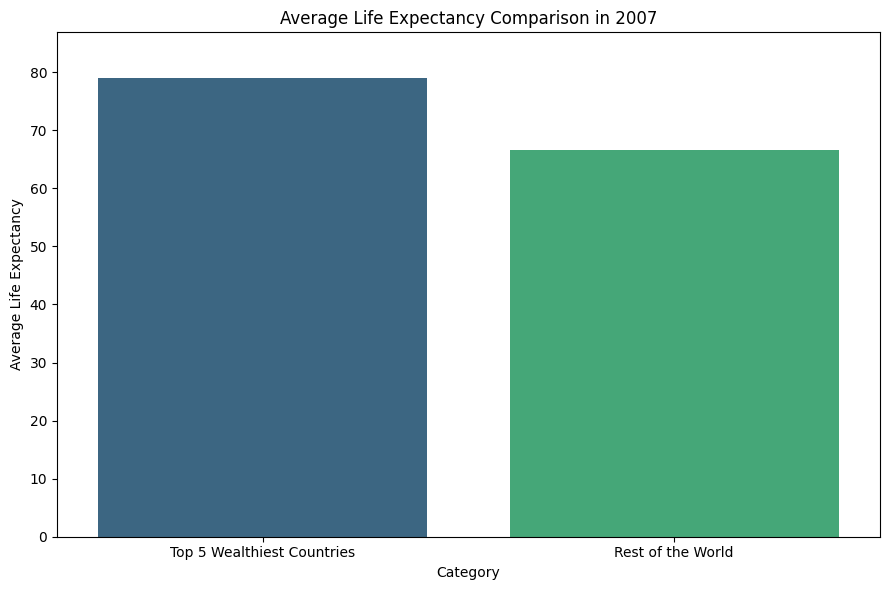

In [ ]:
comparison_data = pd.DataFrame({
    'Category': ['Top 5 Wealthiest Countries', 'Rest of the World'],
    'Average Life Expectancy': [life_exp_top_5, life_exp_rest_of_world]
})

plt.figure(figsize=(9, 6))
sns.barplot(x='Category', y='Average Life Expectancy', data=comparison_data, palette='viridis', hue='Category', legend=False)
plt.title(f'Average Life Expectancy Comparison in {latest_year}')
plt.xlabel('Category')
plt.ylabel('Average Life Expectancy')
plt.ylim(0, max(life_exp_top_5, life_exp_rest_of_world) * 1.1)
plt.tight_layout()
plt.show()

In [ ]:
def calculate_life_expectancy_gap_for_year(data_frame, year_val):
    # Filter data for the current year
    year_data = data_frame[data_frame['year'] == year_val].copy()

    if year_data.empty:
        return None

    # Identify top 5 wealthiest countries for the current year
    top_5_gdp_countries_year = year_data.sort_values(by='gdp_per_capita', ascending=False).head(5)
    top_5_countries_list_year = top_5_gdp_countries_year['country'].tolist()

    # Calculate average life expectancy for top 5 countries
    life_exp_top_5_year = year_data[year_data['country'].isin(top_5_countries_list_year)]['life_expectancy'].mean()

    # Calculate average life expectancy for the rest of the world
    life_exp_rest_of_world_year = year_data[~year_data['country'].isin(top_5_countries_list_year)]['life_expectancy'].mean()

    # Calculate the gap
    gap = life_exp_top_5_year - life_exp_rest_of_world_year

    return gap

# Get all unique years from the cleaned DataFrame
all_years = sorted(df_clean['year'].unique())

# List to store results
gap_data = []

# Calculate gap for each year
for year in all_years:
    gap = calculate_life_expectancy_gap_for_year(df_clean, year)
    if gap is not None:
        gap_data.append({'year': year, 'life_expectancy_gap': gap})

# Create a DataFrame from the results
gap_df = pd.DataFrame(gap_data)

display(gap_df.head())


,year,life_expectancy_gap
0,1952,17.926599
1,1957,16.742732
2,1962,16.087202
3,1967,6.196290
4,1972,6.478945


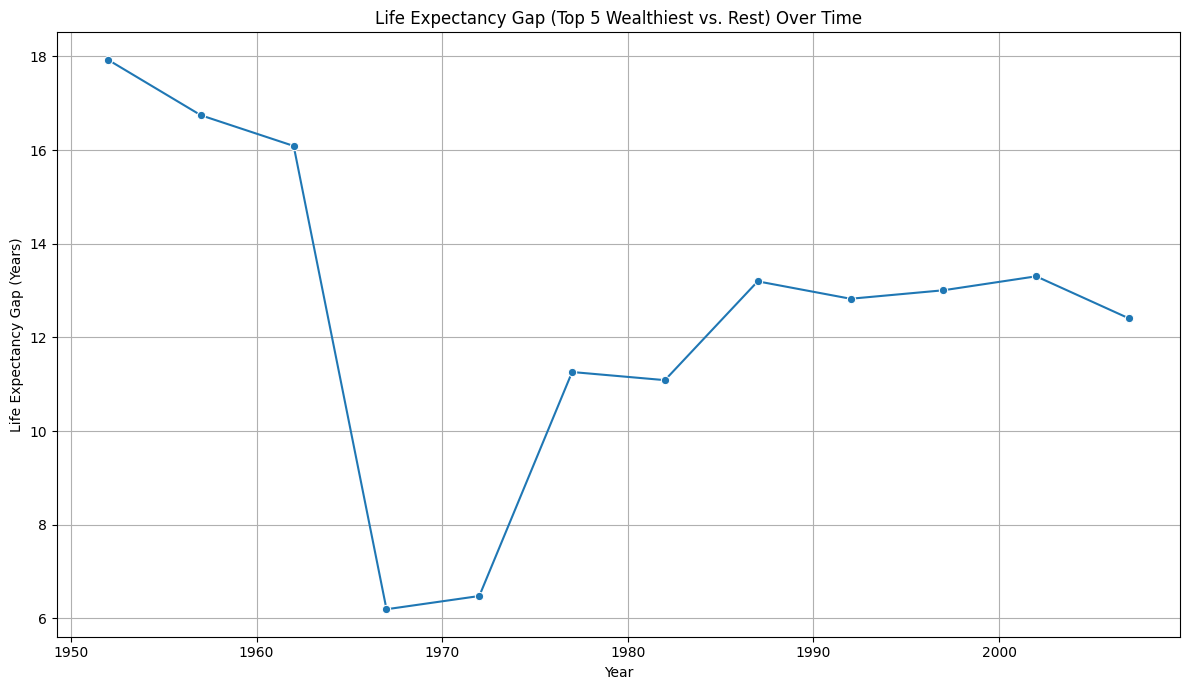

In [ ]:
plt.figure(figsize=(12, 7))
sns.lineplot(x='year', y='life_expectancy_gap', data=gap_df, marker='o')
plt.title('Life Expectancy Gap (Top 5 Wealthiest vs. Rest) Over Time')
plt.xlabel('Year')
plt.ylabel('Life Expectancy Gap (Years)')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Predict life expectancy using the trained model for all data
df_clean['predicted_life_expectancy'] = model.predict(df_clean['gdp_per_capita'].values.reshape(-1, 1))

# Calculate the difference (residual) between actual and predicted life expectancy
df_clean['life_expectancy_residual'] = df_clean['life_expectancy'] - df_clean['predicted_life_expectancy']

# Filter for the latest year to focus on the most recent trend
latest_data_with_residuals = df_clean[df_clean['year'] == latest_year].copy()

# Sort by residual to find the top outperformers (positive residuals)
outperformers = latest_data_with_residuals.sort_values(by='life_expectancy_residual', ascending=False).head(10)

display(outperformers[['country', 'gdp_per_capita', 'life_expectancy', 'predicted_life_expectancy', 'life_expectancy_residual']])


,country,gdp_per_capita,life_expectancy,predicted_life_expectancy,life_expectancy_residual
1655,Vietnam,2441.576404,74.249,55.823080,18.425920
23,Albania,5937.029526,76.423,58.496692,17.926308
395,Cuba,8948.102923,78.273,60.799810,17.473190
359,Costa Rica,9645.061420,78.782,61.332901,17.449099
1667,West Bank and Gaza,3025.349798,73.422,56.269598,17.152402
1499,Syria,4184.548089,74.143,57.156249,16.986751
1115,Nicaragua,2749.320965,72.899,56.058469,16.840531
1271,Reunion,7670.122558,76.442,59.822305,16.619695
455,Ecuador,6873.262326,74.994,59.212800,15.781200
1439,Sri Lanka,3970.095407,72.396,56.992218,15.403782


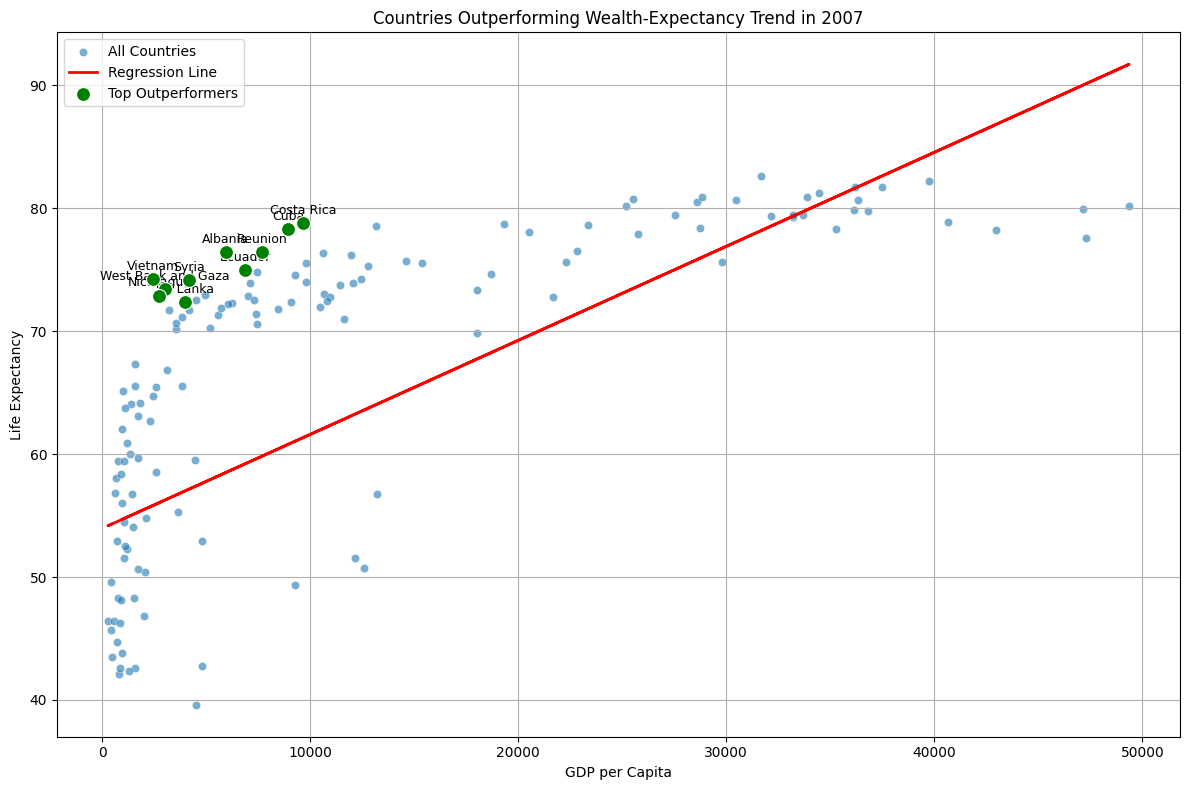

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='gdp_per_capita', y='life_expectancy', data=latest_data_with_residuals, alpha=0.6, label='All Countries')

# Plot the regression line
plt.plot(latest_data_with_residuals['gdp_per_capita'], latest_data_with_residuals['predicted_life_expectancy'], color='red', linewidth=2, label='Regression Line')

# Highlight outperformers
sns.scatterplot(x='gdp_per_capita', y='life_expectancy', data=outperformers, color='green', s=100, label='Top Outperformers', zorder=5)

# Annotate the outperformers
for i, row in outperformers.iterrows():
    plt.text(row['gdp_per_capita'], row['life_expectancy'] + 0.5, row['country'], fontsize=9, ha='center', va='bottom')

plt.title(f'Countries Outperforming Wealth-Expectancy Trend in {latest_year}')
plt.xlabel('GDP per Capita')
plt.ylabel('Life Expectancy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


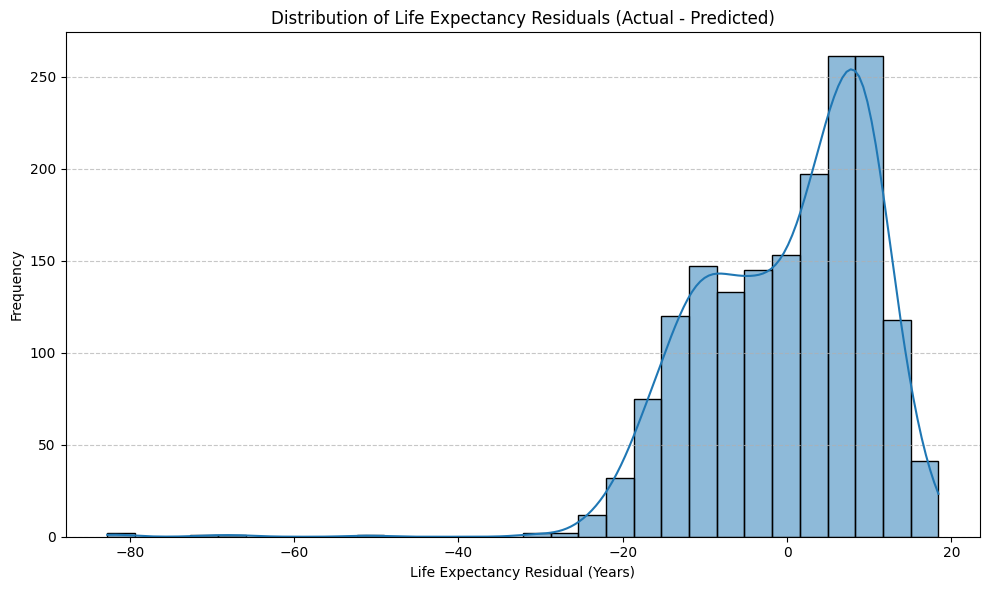

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['life_expectancy_residual'], kde=True, bins=30)
plt.title('Distribution of Life Expectancy Residuals (Actual - Predicted)')
plt.xlabel('Life Expectancy Residual (Years)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
